<a href="https://colab.research.google.com/github/febriyanaft/Analisa-Sentimen-Trigram-SNBP-/blob/main/AF_ATMS_Labeling_%5B2412501591%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [154]:
#@title 2412501591 - Febriyana Triwijayanti

In [155]:
#@title TextBlob - InSet - Vader - Bigram - Trigram

In [156]:
#@title Untuk tugas project Trigram ada di urutan paling akhir

In [157]:
import pandas as pd

df = pd.read_csv('/content/snbp.csv')# ganti nama kolom teks kalau beda
print(df.head())
print(df.info()) #Struktur data

print("Jumlah data:", len(df)) #Jumlah data

   conversation_id_str                      created_at  favorite_count  \
0  2038891259851624874  Tue Mar 31 08:08:51 +0000 2026            7251   
1  2038907937909813573  Tue Mar 31 09:15:08 +0000 2026            6155   
2  2038900509667672248  Tue Mar 31 08:45:37 +0000 2026            7995   
3  2038831758125478317  Tue Mar 31 04:12:25 +0000 2026           12911   
4  2038913740226388414  Tue Mar 31 09:38:11 +0000 2026            4914   

                                           full_text               id_str  \
0  Alhamdulillah ya Allah aku lulus SNBP https://...  2038891259851624874   
1  Sch! TOLONGG KASIH TIPS BELAJAR UTBK DARI 0 DI...  2038907937909813573   
2  tahun lalu aku juga dapet merah di SNBP 2025 t...  2038900509667672248   
3  adek adek snbp unpad 2026 kalo pengumumannya d...  2038831758125478317   
4  ️ dari SD OSN gagal terus ️ gagal lomba yang l...  2038913740226388414   

                                         image_url in_reply_to_screen_name  \
0  https://pbs

In [158]:
print(df.columns)

Index(['conversation_id_str', 'created_at', 'favorite_count', 'full_text',
       'id_str', 'image_url', 'in_reply_to_screen_name', 'lang', 'location',
       'quote_count', 'reply_count', 'retweet_count', 'tweet_url',
       'user_id_str', 'username'],
      dtype='object')


In [159]:
import re

def clean_text(full_text):
  full_text = full_text.lower()
  full_text = re.sub(r"http\S+", "", full_text)
  full_text = re.sub(r"@\w+", "", full_text)
  full_text = re.sub(r"[^a-zA-Z\s]", "", full_text)
  return full_text

df['clean_text'] = df['full_text'].apply(clean_text)

In [160]:
df[['full_text', 'clean_text']].head()

,full_text,clean_text
0,Alhamdulillah ya Allah aku lulus SNBP https://...,alhamdulillah ya allah aku lulus snbp
1,Sch! TOLONGG KASIH TIPS BELAJAR UTBK DARI 0 DI...,sch tolongg kasih tips belajar utbk dari di h...
2,tahun lalu aku juga dapet merah di SNBP 2025 t...,tahun lalu aku juga dapet merah di snbp tapi ...
3,adek adek snbp unpad 2026 kalo pengumumannya d...,adek adek snbp unpad kalo pengumumannya delay...
4,️ dari SD OSN gagal terus ️ gagal lomba yang l...,dari sd osn gagal terus gagal lomba yang lai...


In [161]:
df_sample = df[['full_text']].head(10)
df_sample

,full_text
0,Alhamdulillah ya Allah aku lulus SNBP https://...
1,Sch! TOLONGG KASIH TIPS BELAJAR UTBK DARI 0 DI...
2,tahun lalu aku juga dapet merah di SNBP 2025 t...
3,adek adek snbp unpad 2026 kalo pengumumannya d...
4,️ dari SD OSN gagal terus ️ gagal lomba yang l...
5,demi apa sih lolos snbp stei-k itb ⁉️ #snbp202...
6,ALHAMDULILLAHHHH JADI PEMBUKA BUAT DEKEL ITUUU...
7,emg snbp tuh ghaib bgt yh... di sekolah gw eli...
8,alhamdulillah furab lolos snbp https://t.co/Ao...
9,GUYS AKU LOLOS TEKKIM UNDIPPP https://t.co/LdY...


In [162]:
opini_keywords = [
    'aku', 'saya', 'menurut', 'rasanya', 'kayaknya',
    'senang', 'bahagia', 'bangga', 'kecewa', 'sedih',
    'stress', 'bingung', 'ribet', 'sulit'
]
berita_keywords = [
    'snbp', 'pengumuman', 'hasil', 'jadwal', 'resmi',
    'seleksi', 'ptn', 'kuota', 'pendaftaran', 'diumumkan'
]

def label_otomatis(text):
    text = str(text).lower()

    if any(word in text for word in opini_keywords):
        return 'opini'
    elif any(word in text for word in berita_keywords):
        return 'berita'
    else:
        return 'opini'  # fallback default

In [163]:
#@title 2412501591 - TextBlob

In [164]:
from textblob import TextBlob
df['tb'] = df['full_text'].apply(lambda x:
TextBlob(str(x)).sentiment.polarity)

In [165]:
from textblob import TextBlob

def sentiment_textblob(text):
  return TextBlob(str(text)).sentiment.polarity

df['sentiment_tb'] = df['full_text'].apply(sentiment_textblob)

In [166]:
def label_tb(score):
    if score > 0:
        return 'Positif'
    elif score < 0:
        return 'Negatif'
    else:
        return 'Netral'

df['label_tb'] = df['sentiment_tb'].apply(label_tb)

In [167]:
df[['full_text','sentiment_tb','label_tb']].head(10)

,full_text,sentiment_tb,label_tb
0,Alhamdulillah ya Allah aku lulus SNBP https://...,0.0,Netral
1,Sch! TOLONGG KASIH TIPS BELAJAR UTBK DARI 0 DI...,0.0,Netral
2,tahun lalu aku juga dapet merah di SNBP 2025 t...,0.0,Netral
3,adek adek snbp unpad 2026 kalo pengumumannya d...,0.0,Netral
4,️ dari SD OSN gagal terus ️ gagal lomba yang l...,0.0,Netral
5,demi apa sih lolos snbp stei-k itb ⁉️ #snbp202...,0.0,Netral
6,ALHAMDULILLAHHHH JADI PEMBUKA BUAT DEKEL ITUUU...,0.0,Netral
7,emg snbp tuh ghaib bgt yh... di sekolah gw eli...,0.0,Netral
8,alhamdulillah furab lolos snbp https://t.co/Ao...,0.0,Netral
9,GUYS AKU LOLOS TEKKIM UNDIPPP https://t.co/LdY...,0.0,Netral


In [168]:
print("Distribusi Sentimen TextBlob:")
print(df['label_tb'].value_counts())

Distribusi Sentimen TextBlob:
label_tb
Netral     104
Positif      8
Negatif      2
Name: count, dtype: int64


In [169]:
#@title 2412501591 - Vader

In [170]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [171]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

def sentiment_vader(text):
  return sia.polarity_scores(str(text))['compound']

df['sentiment_vader'] = df['full_text'].apply(sentiment_vader)

In [172]:
def label_vader(score):
  if score > 0:
    return 'Positif'
  elif score < 0:
    return 'Negatif'
  else:
    return 'Netral'

df['label_vader'] = df['sentiment_vader'].apply(label_vader)

In [173]:
print("Distribusi Sentimen VADER:")
print(df['label_vader'].value_counts())

Distribusi Sentimen VADER:
label_vader
Netral     89
Positif    15
Negatif    10
Name: count, dtype: int64


In [174]:
df[['full_text','label_tb','label_vader']].head(10)

,full_text,label_tb,label_vader
0,Alhamdulillah ya Allah aku lulus SNBP https://...,Netral,Netral
1,Sch! TOLONGG KASIH TIPS BELAJAR UTBK DARI 0 DI...,Netral,Positif
2,tahun lalu aku juga dapet merah di SNBP 2025 t...,Netral,Netral
3,adek adek snbp unpad 2026 kalo pengumumannya d...,Netral,Negatif
4,️ dari SD OSN gagal terus ️ gagal lomba yang l...,Netral,Netral
5,demi apa sih lolos snbp stei-k itb ⁉️ #snbp202...,Netral,Netral
6,ALHAMDULILLAHHHH JADI PEMBUKA BUAT DEKEL ITUUU...,Netral,Netral
7,emg snbp tuh ghaib bgt yh... di sekolah gw eli...,Netral,Netral
8,alhamdulillah furab lolos snbp https://t.co/Ao...,Netral,Netral
9,GUYS AKU LOLOS TEKKIM UNDIPPP https://t.co/LdY...,Netral,Netral


In [175]:
#@title 2412501591 - Inset

In [176]:
pos_lex = pd.read_csv('/content/positive.tsv', sep='\t')
neg_lex = pd.read_csv('/content/negative.tsv', sep='\t')

In [177]:
print(pos_lex.columns)
print(neg_lex.head())

Index(['word', 'weight'], dtype='object')
                   word  weight
0    putus tali gantung      -2
1               gelebah      -2
2            gobar hati      -2
3  tersentuh (perasaan)      -1
4                  isak      -5


In [178]:
print(pos_lex.columns)
print(pos_lex.head())

Index(['word', 'weight'], dtype='object')
        word  weight
0        hai       3
1    merekam       2
2  ekstensif       3
3  paripurna       1
4     detail       2


In [179]:
positive_words = dict(zip(pos_lex['word'], pos_lex['weight']))
negative_words = dict(zip(neg_lex['word'], neg_lex['weight']))

In [180]:
def sentiment_inset(text):
  score = 0
  for word in str(text).split():
    if word in positive_words:
      score += positive_words[word]
    elif word in negative_words:
      score += negative_words[word]
  return score

df['sentiment_score'] = df['clean_text'].apply(sentiment_inset)

In [181]:
def label(score):
  if score > 0:
    return 'Positif'
  elif score < 0:
    return 'Negatif'
  else:
    return 'Netral'

df['sentiment_label'] = df['sentiment_score'].apply(label)

In [182]:
df[['full_text','clean_text','sentiment_score','sentiment_label']].head()

,full_text,clean_text,sentiment_score,sentiment_label
0,Alhamdulillah ya Allah aku lulus SNBP https://...,alhamdulillah ya allah aku lulus snbp,21,Positif
1,Sch! TOLONGG KASIH TIPS BELAJAR UTBK DARI 0 DI...,sch tolongg kasih tips belajar utbk dari di h...,-2,Negatif
2,tahun lalu aku juga dapet merah di SNBP 2025 t...,tahun lalu aku juga dapet merah di snbp tapi ...,20,Positif
3,adek adek snbp unpad 2026 kalo pengumumannya d...,adek adek snbp unpad kalo pengumumannya delay...,-4,Negatif
4,️ dari SD OSN gagal terus ️ gagal lomba yang l...,dari sd osn gagal terus gagal lomba yang lai...,-28,Negatif


In [183]:
sentimen_summary = df['sentiment_label'].value_counts().reset_index()
sentimen_summary.columns = ['Sentimen', 'Jumlah']
print(sentimen_summary)

  Sentimen  Jumlah
0  Positif      70
1  Negatif      36
2   Netral       8


In [184]:
df['sentiment_label'].value_counts()

,count
sentiment_label,
Positif,70
Negatif,36
Netral,8


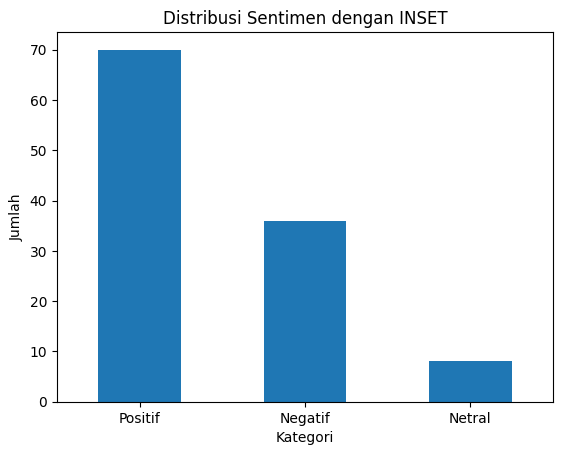

In [185]:
import matplotlib.pyplot as plt

df['sentiment_label'].value_counts().plot(kind='bar')
plt.title("Distribusi Sentimen dengan INSET")
plt.xlabel("Kategori")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)
plt.show()

In [186]:
#@title 2412501591 - Bigram Analisis

In [187]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Bigram
vectorizer = CountVectorizer(ngram_range=(2, 2))

X = vectorizer.fit_transform(df['clean_text'])

bigram_counts = X.toarray().sum(axis=0)
bigram_features = vectorizer.get_feature_names_out()

bigram_df = pd.DataFrame({
  'bigram': bigram_features,
  'count': bigram_counts
})

bigram_df = bigram_df.sort_values(by='count', ascending=False)
bigram_df.head(20)

,bigram,count
922,lolos snbp,29
718,jalur snbp,11
1649,ya allah,10
937,lulus snbp,7
1136,pengumuman snbp,7
943,maba ptn,6
604,hari ini,6
704,jadi maba,6
719,jam menuju,6
1187,ptn jalur,6


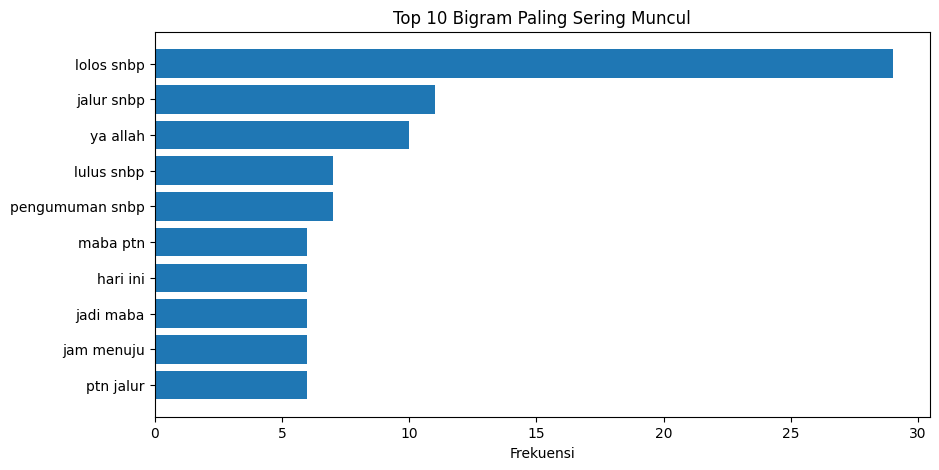

In [188]:
import matplotlib.pyplot as plt

top_bigram = bigram_df.head(10)

plt.figure(figsize=(10,5))
plt.barh(top_bigram['bigram'], top_bigram['count'])
plt.gca().invert_yaxis()
plt.title("Top 10 Bigram Paling Sering Muncul")
plt.xlabel("Frekuensi")
plt.show()

In [189]:
print(pos_lex.head())
print(neg_lex.head())

        word  weight
0        hai       3
1    merekam       2
2  ekstensif       3
3  paripurna       1
4     detail       2
                   word  weight
0    putus tali gantung      -2
1               gelebah      -2
2            gobar hati      -2
3  tersentuh (perasaan)      -1
4                  isak      -5


In [190]:
positive_words = dict(zip(pos_lex['word'], pos_lex['weight']))
negative_words = dict(zip(neg_lex['word'], neg_lex['weight']))

In [191]:
topic = "lolos snbp"
topic_df = df[df['clean_text'].str.contains(topic, na=False)]
topic_df['sentiment_label'].value_counts()

,count
sentiment_label,
Positif,17
Negatif,10
Netral,1


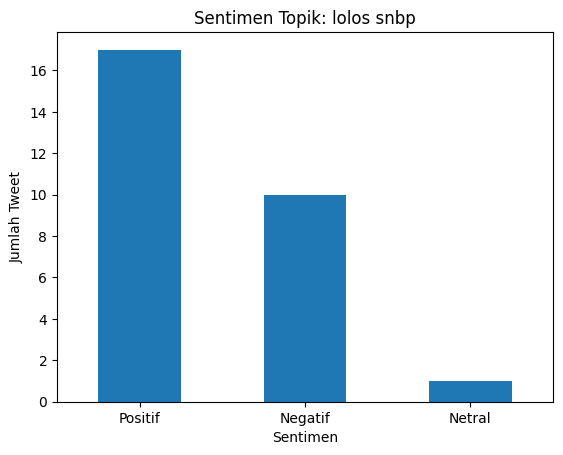

In [192]:
import matplotlib.pyplot as plt

topic_df['sentiment_label'].value_counts().plot(kind='bar')
plt.title(f"Sentimen Topik: {topic}")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Tweet")
plt.xticks(rotation=0)
plt.show()

In [193]:
top_bigram = bigram_df.head(5)['bigram'].tolist()
print(top_bigram)

['lolos snbp', 'jalur snbp', 'ya allah', 'lulus snbp', 'pengumuman snbp']


In [194]:
for topic in top_bigram:
  print(f"\nTopik: {topic}")
  topic_df = df[df['clean_text'].str.contains(topic, na=False)]
  print(topic_df['sentiment_label'].value_counts())


Topik: lolos snbp
sentiment_label
Positif    17
Negatif    10
Netral      1
Name: count, dtype: int64

Topik: jalur snbp
sentiment_label
Negatif    5
Positif    2
Name: count, dtype: int64

Topik: ya allah
sentiment_label
Positif    7
Negatif    1
Name: count, dtype: int64

Topik: lulus snbp
sentiment_label
Positif    7
Name: count, dtype: int64

Topik: pengumuman snbp
sentiment_label
Negatif    4
Positif    3
Name: count, dtype: int64


In [195]:
#@title 2412501591 - Trigram Analisis

In [196]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Trigram
vectorizer = CountVectorizer(ngram_range=(3, 3))

X = vectorizer.fit_transform(df['clean_text'])

trigram_counts = X.toarray().sum(axis=0)
trigram_features = vectorizer.get_feature_names_out()

trigram_df = pd.DataFrame({
  'trigram': trigram_features,
  'count': trigram_counts
})

trigram_df = trigram_df.sort_values(by='count', ascending=False)

trigram_df.head(10)

,trigram,count
983,maba ptn jalur,6
717,jadi maba ptn,6
1225,ptn jalur snbp,6
1127,officially jadi maba,5
1421,snbp jam menuju,5
1047,menuju officially jadi,5
736,jam menuju officially,5
732,jalur snbp jam,5
944,lolos snbp di,3
1724,yang lolos snbp,3


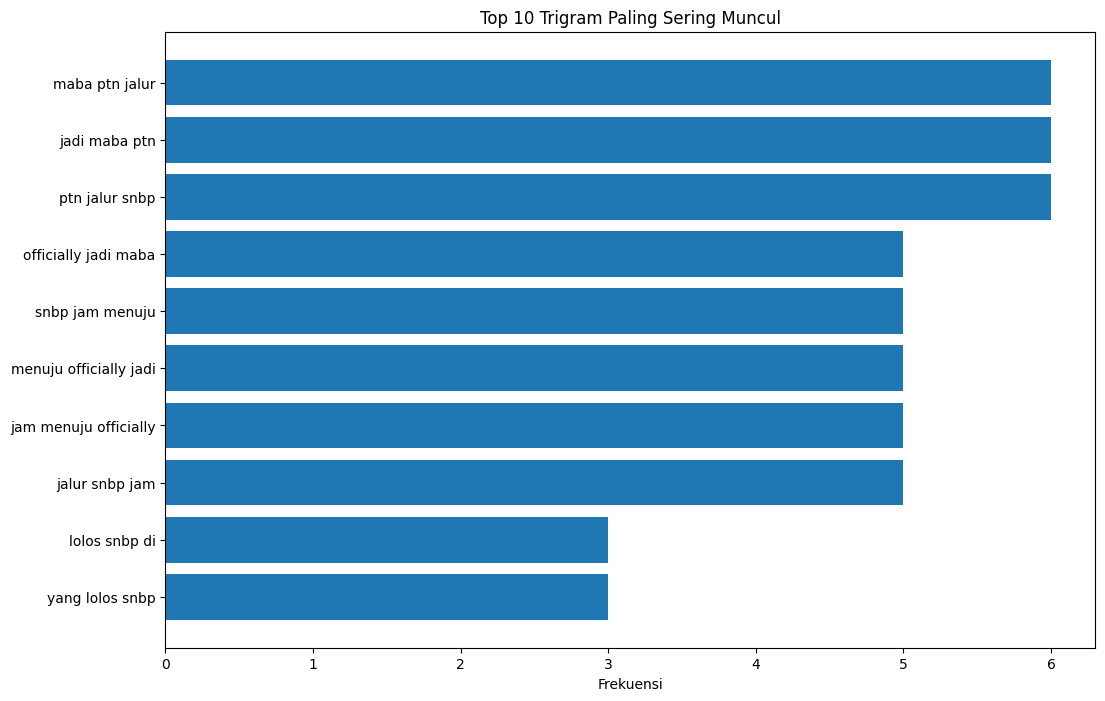

In [197]:
import matplotlib.pyplot as plt

top_trigram = trigram_df.head(10)

plt.figure(figsize=(12,8))
plt.barh(top_trigram['trigram'], top_trigram['count'])
plt.gca().invert_yaxis()
plt.title("Top 10 Trigram Paling Sering Muncul")
plt.xlabel("Frekuensi")
plt.show()

In [198]:
print(pos_lex.head())
print(neg_lex.head())

        word  weight
0        hai       3
1    merekam       2
2  ekstensif       3
3  paripurna       1
4     detail       2
                   word  weight
0    putus tali gantung      -2
1               gelebah      -2
2            gobar hati      -2
3  tersentuh (perasaan)      -1
4                  isak      -5


In [199]:
positive_words = dict(zip(pos_lex['word'], pos_lex['weight']))
negative_words = dict(zip(neg_lex['word'], neg_lex['weight']))

In [200]:
print(trigram_df.head(10))

                     trigram  count
983           maba ptn jalur      6
717            jadi maba ptn      6
1225          ptn jalur snbp      6
1127    officially jadi maba      5
1421         snbp jam menuju      5
1047  menuju officially jadi      5
736    jam menuju officially      5
732           jalur snbp jam      5
944            lolos snbp di      3
1724         yang lolos snbp      3


In [201]:
topic = "lolos snbp 2026"
topic_df = df[df['clean_text'].str.contains("lolos.*snbp", na=False)]
topic_df['sentiment_label'].value_counts()

,count
sentiment_label,
Positif,22
Negatif,11
Netral,1


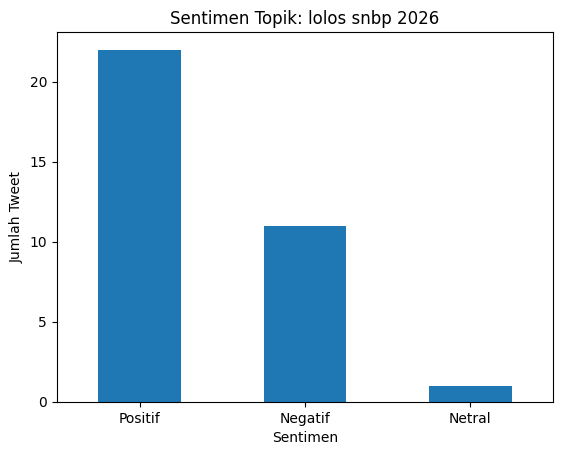

In [202]:
import matplotlib.pyplot as plt

topic_df['sentiment_label'].value_counts().plot(kind='bar')
plt.title(f"Sentimen Topik: {topic}")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Tweet")
plt.xticks(rotation=0)
plt.show()

In [203]:
top_trigram = trigram_df.head(10)['trigram'].tolist()
print(top_trigram)

['maba ptn jalur', 'jadi maba ptn', 'ptn jalur snbp', 'officially jadi maba', 'snbp jam menuju', 'menuju officially jadi', 'jam menuju officially', 'jalur snbp jam', 'lolos snbp di', 'yang lolos snbp']


In [204]:
for topic in top_trigram:
  print(f"\nTopik: {topic}")
  topic_df = df[df['clean_text'].str.contains(topic, na=False)]
  print(topic_df['sentiment_label'].value_counts())


Topik: maba ptn jalur
sentiment_label
Negatif    2
Name: count, dtype: int64

Topik: jadi maba ptn
sentiment_label
Negatif    2
Name: count, dtype: int64

Topik: ptn jalur snbp
sentiment_label
Negatif    2
Name: count, dtype: int64

Topik: officially jadi maba
sentiment_label
Negatif    1
Name: count, dtype: int64

Topik: snbp jam menuju
Series([], Name: count, dtype: int64)

Topik: menuju officially jadi
sentiment_label
Negatif    1
Name: count, dtype: int64

Topik: jam menuju officially
sentiment_label
Negatif    1
Name: count, dtype: int64

Topik: jalur snbp jam
Series([], Name: count, dtype: int64)

Topik: lolos snbp di
sentiment_label
Positif    1
Name: count, dtype: int64

Topik: yang lolos snbp
sentiment_label
Negatif    3
Name: count, dtype: int64
